In [1]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from inflation_forecast.pre_process import stationary_transform, report_missings, sample_split, remove_missing_col, create_ahead_lag
from inflation_forecast.visualization import visualize_series
from inflation_forecast.feature_engineering import create_fe_pipeline

In [2]:
# read the FRED_MD csv file, convert to pandas dataframe
root_dir = Path.cwd().parent
FRED_MD = pd.read_csv(str(root_dir) + "/data/FRED_MD/2026-02-MD.csv")
transforms = pd.read_csv(str(root_dir) + "/data/FRED_MD/transform.csv")

In [3]:
# conduct stationarity transformations
FRED_transformed = stationary_transform(FRED_MD, transforms)
# drop first two rows as they have abundant nan due to double difference
FRED_transformed = FRED_transformed.iloc[2:]
# drop last row as many variables of it has not updated
FRED_transformed = FRED_transformed.iloc[:-1]
# transform sasdate to pd.date format
FRED_transformed["sasdate"] = pd.to_datetime(FRED_transformed["sasdate"])

In [4]:
# print missing value counts and percentage in each column
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

In [5]:
# drop columns with > 10% missing values
FRED_transformed = remove_missing_col(FRED_transformed)
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

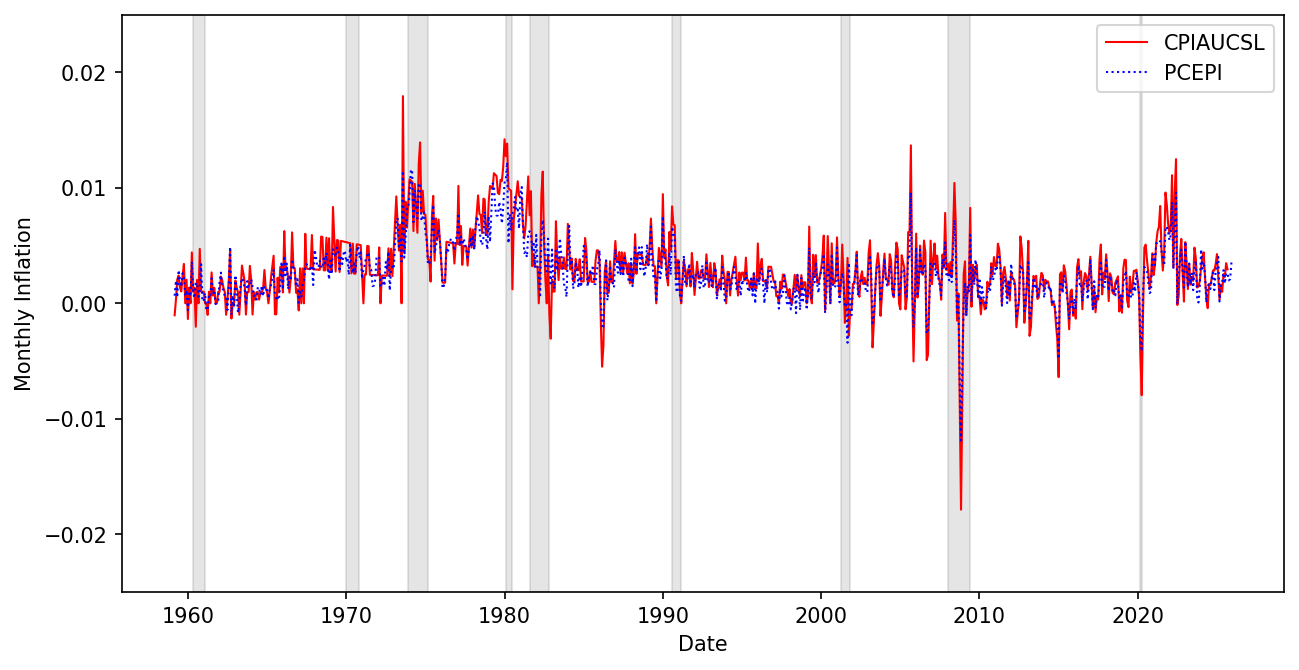

In [6]:
# plot CPIAUCSL and PCEPI over time
visualize_series(FRED_transformed, ["CPIAUCSL", "PCEPI"], "Monthly Inflation", -0.025, 0.025)

In [7]:
# split train and test set
FRED_tt = FRED_transformed.drop(columns = ["sasdate"])
train_set, test_set = sample_split(FRED_tt, 0.8)
# create feature engineering pipeline
feature_engineering = create_fe_pipeline()
# fit the feature engineering pipeline
feature_engineering.fit(train_set)
# uses the fitted pipeline to transform the whole dataset
FRED_tt = feature_engineering.transform(FRED_tt)
# create aheads and lags
max_lag = 48
max_ahead = 24
FRED_tt, targets = create_ahead_lag(FRED_tt, "CPIAUCSL", max_ahead, max_lag)
# re-split the transformed dataset
train_set, test_set = sample_split(FRED_tt, 0.8)
# drop first max_lag rows and last max_ahead rows
train_set = train_set.iloc[max_lag:]
test_set = train_set.iloc[:max_ahead]
# extract X and Y from train set and test set
y_train = train_set[targets]
x_train = train_set.drop(columns = targets)
y_test = test_set[targets]
x_test = test_set.drop(columns = targets)

/Users/yuhaohuo/Desktop/code/d200_project/inflation_forecast/pre_process.py:134: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_frame[f"{column}_{i}L"] = new_frame[column].shift(i)


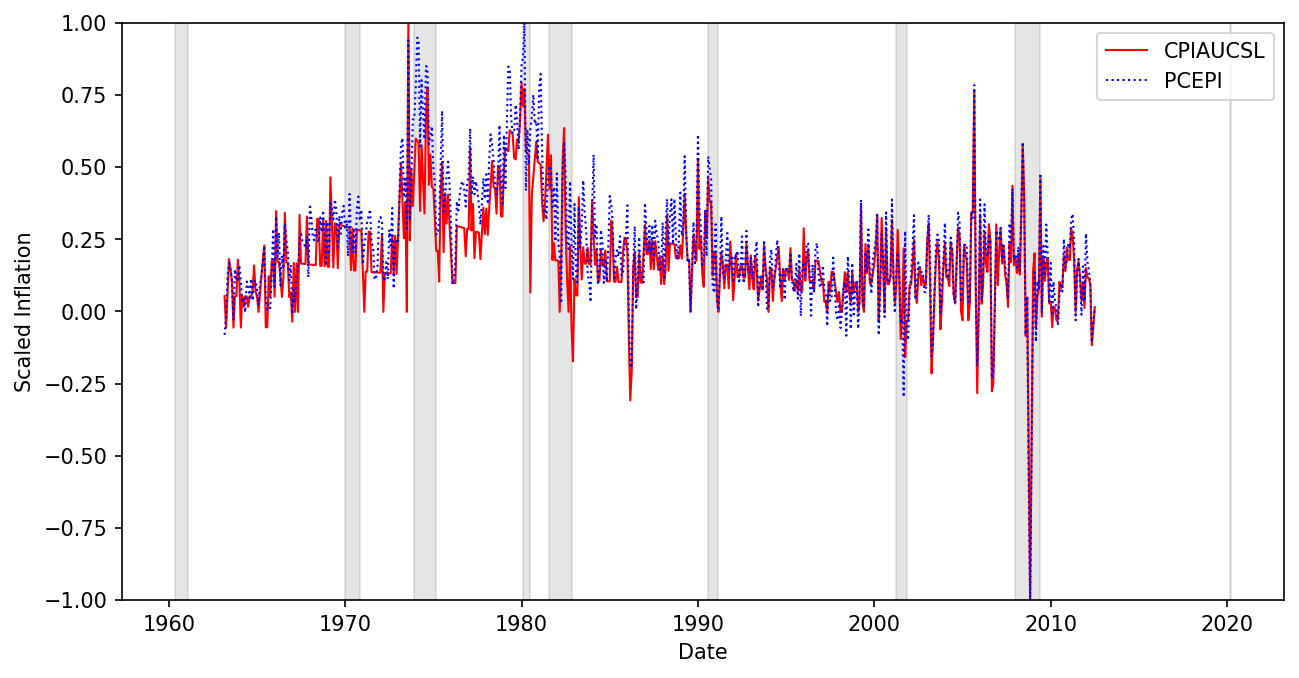

In [8]:
# plot min-max scaled CPIAUCSL and PCEPI over time
y_train_date = y_train.merge(FRED_transformed["sasdate"], left_index=True, right_index=True, how="left")
temp_complete = y_train_date.merge(x_train, left_index=True, right_index=True, how="left")
visualize_series(temp_complete, ["CPIAUCSL", "PCEPI"], "Scaled Inflation", -1, 1)

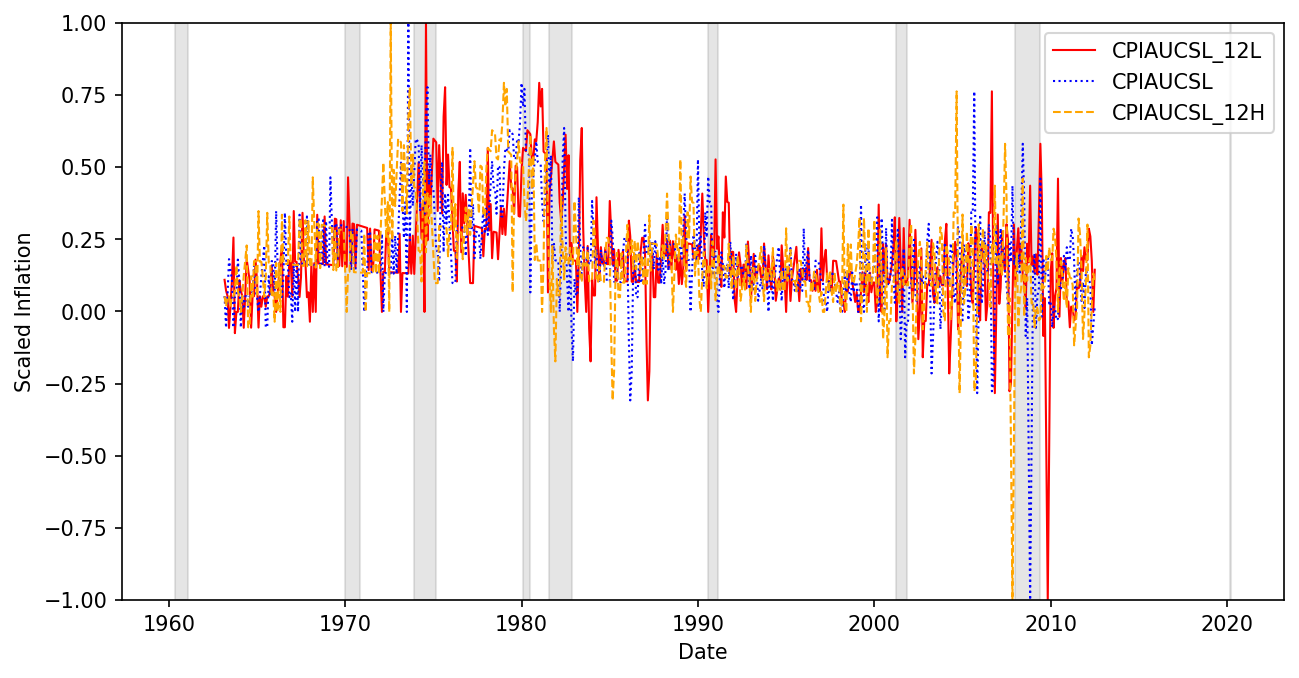

In [9]:
# plot lags and aheads of CPIAUCSL with same horizon
visualize_series(temp_complete, ["CPIAUCSL_12L", "CPIAUCSL", "CPIAUCSL_12H"], "Scaled Inflation", -1, 1)